In [1]:
# Project: Student Exam Prediction
# Business Problem
# A school wants to predict whether a studnet will pass (1) or Fail (0) before the final exam

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Step 2: Create Dataset

In [2]:
data = {
    "Study_Hours":[2,3,4,5,6,7,8,2,1,6,7,5,4,8,9,10,3,6,7,5],
    "Attendance":[55,60,65,70,75,80,90,50,45,78,85,72,68,92,95,98,60,82,88,74],
    "Assignments":[1,2,2,3,4,5,5,1,0,4,5,3,2,5,5,5,2,4,5,3],
    "Result":[0,0,0,0,1,1,1,0,0,1,1,1,0,1,1,1,0,1,1,1]
}

df = pd.DataFrame(data)

print(df.head())

   Study_Hours  Attendance  Assignments  Result
0            2          55            1       0
1            3          60            2       0
2            4          65            2       0
3            5          70            3       0
4            6          75            4       1


# Check Dataset

In [3]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(20, 4)
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  20 non-null     int64
 1   Attendance   20 non-null     int64
 2   Assignments  20 non-null     int64
 3   Result       20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None
       Study_Hours  Attendance  Assignments     Result
count    20.000000   20.000000    20.000000  20.000000
mean      5.400000   74.100000     3.300000   0.600000
std       2.458069   15.109774     1.625455   0.502625
min       1.000000   45.000000     0.000000   0.000000
25%       3.750000   63.750000     2.000000   0.000000
50%       5.500000   74.500000     3.500000   1.000000
75%       7.000000   85.750000     5.000000   1.000000
max      10.000000   98.000000     5.000000   1.000000
Study_Hours    0
Attendance     0
Assignments    0
Result         0
dtype: int64


# Feature & Target

In [4]:
X= df.drop("Result", axis=1)
y= df["Result"]

# Step 5: Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 6: Train Logistic Regression
This line trains the model.

Internally the model:

Initializes weights,Initializes bias, Uses Sigmoid Function, Uses Log Loss, Uses Gradient Descent, Learns best weights

In [6]:
# What Happens Inside model.fit()?
# When you write: model.fit(X_train, y_train)
# Scikit-learn performs these steps internally:
# Initialize Weight = 0
# Initialize Bias = 0
# Calculate
# z = wX + b
# Apply Sigmoid
# Find Probability
# Calculate Log Loss
# Gradient Descent
# Update Weight
# Update Bias
# Repeat Thousands of Times
# Best Model Ready

model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# Step 7: Prediciton

In [7]:
y_pred = model.predict(X_test) #Probability Prediction
print(y_pred)

[0 1 1 0]


In [8]:
y_probability = model.predict_proba(X_test)
print(y_probability)

[[9.99999832e-01 1.68456442e-07]
 [2.25939289e-05 9.99977406e-01]
 [3.63509223e-12 1.00000000e+00]
 [9.99976934e-01 2.30656966e-05]]


# Step 8: Accuracy


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


# Step 9: Confusion Matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 0]
 [0 2]]


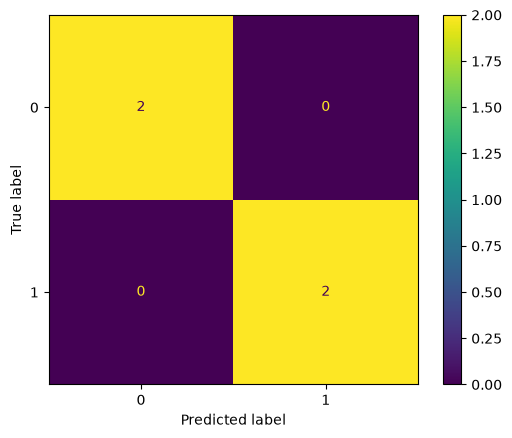

In [11]:
disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

# Step 10: Classification Report

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Step 11: ROC Curve

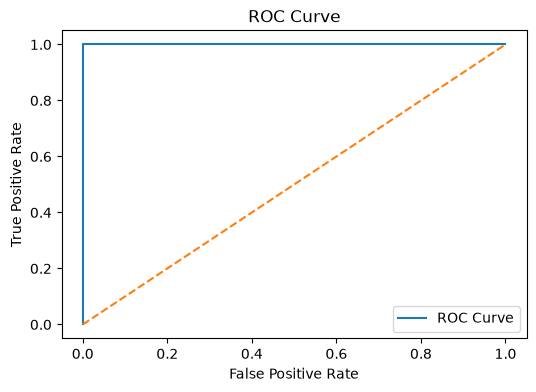

In [13]:
#Recover Operating Characteristic is used to evaluate how well a classification model distinguishes between two classes.
##It shows True Positive Rate(TPR) on the Y-axix
##False Positive Rate (FPR) on the X-axix

probability = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    probability
)

plt.figure(figsize=(6,4))

plt.plot(fpr,tpr,label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Step 12: ROC AUC Score

In [14]:
score = roc_auc_score(y_test, probability)

print(score)

1.0


# Step 13: Predict New Student

Suppose

Study Hours = 6

Attendance = 80

Assignments = 4

In [15]:
new_student = [[6,80,4]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction : PASS")
else:
    print("Prediction : FAIL")

Prediction : PASS


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Step 12: Prediction Probability

In [16]:
probability = model.predict_proba(new_student)

print("Fail Probability =", probability[0][0])
print("Pass Probability =", probability[0][1])

Fail Probability = 0.00015268167787718667
Pass Probability = 0.9998473183221228


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
